# 📊 ML Project Progress Tracker

## 🔹 1. Data Understanding

* [x] Loaded dataset
* [x] Explored columns and data types
* [x] Checked unique values
* [x] Identified categorical vs numerical features

---

## 🔹 2. Data Cleaning

* [x] Removed unnecessary columns (e.g. `student_id`)
* [x] Handled categorical values (yes/no → 1/0)

---

## 🔹 3. Encoding

* [x] One-Hot Encoding → (gender, study_method)
* [x] Ordinal Encoding → (parent_education, travel_time)
* [x] Understood when to use each type

---

## 🔹 4. Feature Understanding (EDA)

### 📈 Distributions

* [x] Plotted histograms
* [x] Observed data shape (normal / uniform)

---

### 🔗 Relationships (Numerical vs Numerical)

* [x] study_hours vs overall_score

* [x] attendance vs overall_score

* [x] study_hours vs attendance

* [x] Used scatter plots

* [x] Added correlation values

* [] Identified independent variables

---

### 📊 Categorical Impact

* [x] external_activities vs score

* [x] school_type vs score

* [x] Used boxplots

* [x] Compared distributions

---

### 🔥 Advanced Visualization

* [x] Used pairplot
* [x] Removed redundant plots (triangle only)
* [x] Removed diagonal (self plots)
* [x] Improved layout

---

## 🔹 5. Key Insights

* [x] study_hours affects score
* [x] attendance has weaker effect
* [x] no relation between study_hours & attendance
* [x] subject scores highly correlated
* [x] overall_score depends on subjects

---

## 🔹 6. Data Preparation for ML

* [x] Select final features
* [x] Apply scaling (StandardScaler)
* [x] Split data (train/test)

---

## 🔹 7. Modeling

* [x] Choose model (Linear Regression)
* [x] Train model
* [x] Predict

---

## 🔹 8. Evaluation

* [x] Evaluate performance
* [x] Analyze errors

---

## 🧠 Notes

* Scaling → only for numerical features
* Do NOT scale one-hot or binary
* Drop unnecessary features (IDs)
* Check correlation before modeling


In [1]:
from pathlib import Path
import shutil
import kagglehub

# Returns the local cache path (downloads only if needed)
path = kagglehub.dataset_download("kundanbedmutha/student-performance-dataset")
source_dir = Path(path)

cwd = Path.cwd().parent

target_dir = cwd if cwd.name.lower() == "Data" else cwd / "Data"
target_dir.mkdir(parents=True, exist_ok=True)

for item in source_dir.iterdir():
    destination = target_dir / item.name

    if destination.exists():
        if destination.is_dir():
            shutil.rmtree(destination)
        else:
            destination.unlink()

    shutil.move(str(item), str(destination))

# Clean up empty source directory if everything was moved
if source_dir.exists() and not any(source_dir.iterdir()):
    source_dir.rmdir()

print(f"Dataset moved from: {source_dir}")
print(f"Dataset moved to:   {target_dir}")

e:\Documents\AI\Student_Performance\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset moved from: C:\Users\ASUD Vivo\.cache\kagglehub\datasets\kundanbedmutha\student-performance-dataset\versions\1
Dataset moved to:   e:\Documents\AI\Student_Performance\Data


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kundanbedmutha/student-performance-dataset")

print("Path to dataset files:", path)

100%|██████████| 516k/516k [00:00<00:00, 939kB/s]

Extracting files...
Path to dataset files: C:\Users\ASUD Vivo\.cache\kagglehub\datasets\kundanbedmutha\student-performance-dataset\versions\1


In [3]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("E:\Documents\AI\Student_Performance\Data\Student_Performance.csv")

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\ASUD Vivo\AppData\Local\Temp\ipykernel_3548\1837386673.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  df = pd.read_csv("E:\Documents\AI\Student_Performance\Data\Student_Performance.csv")


In [5]:
df

,student_id,age,gender,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,study_method,math_score,science_score,english_score,overall_score,final_grade
0,1,14,male,public,post graduate,3.1,84.3,yes,<15 min,yes,notes,42.7,55.4,57.0,53.1,e
1,2,18,female,public,graduate,3.7,87.8,yes,>60 min,no,textbook,57.6,68.8,64.8,61.3,d
2,3,17,female,private,post graduate,7.9,65.5,no,<15 min,no,notes,84.8,95.0,79.2,89.6,b
3,4,16,other,public,high school,1.1,58.1,no,15-30 min,no,notes,44.4,27.5,54.7,41.6,e
4,5,16,female,public,high school,1.3,61.0,yes,30-60 min,yes,group study,8.9,32.7,30.0,25.4,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,female,public,phd,1.8,55.2,yes,15-30 min,no,mixed,55.8,48.5,46.7,46.1,e
24996,1102,16,female,private,diploma,2.7,97.1,yes,<15 min,no,coaching,64.8,48.2,52.3,56.5,d
24997,4422,19,other,private,post graduate,1.0,63.0,yes,<15 min,no,group study,50.5,20.3,36.1,36.7,f
24998,7858,14,male,private,diploma,1.0,69.4,yes,15-30 min,yes,group study,13.0,34.2,7.3,34.1,f


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             25000 non-null  int64  
 1   age                    25000 non-null  int64  
 2   gender                 25000 non-null  str    
 3   school_type            25000 non-null  str    
 4   parent_education       25000 non-null  str    
 5   study_hours            25000 non-null  float64
 6   attendance_percentage  25000 non-null  float64
 7   internet_access        25000 non-null  str    
 8   travel_time            25000 non-null  str    
 9   extra_activities       25000 non-null  str    
 10  study_method           25000 non-null  str    
 11  math_score             25000 non-null  float64
 12  science_score          25000 non-null  float64
 13  english_score          25000 non-null  float64
 14  overall_score          25000 non-null  float64
 15  final_grade  

In [7]:
df.describe()

,student_id,age,study_hours,attendance_percentage,math_score,science_score,english_score,overall_score
count,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,7493.04380,16.482760,4.253224,75.084084,63.785944,63.745320,63.681948,64.006172
std,4323.56215,1.703895,2.167541,14.373171,20.875262,20.970529,20.792693,18.932025
min,1.00000,14.000000,0.500000,50.000000,0.000000,0.000000,0.000000,14.500000
25%,3743.75000,15.000000,2.400000,62.800000,48.300000,48.200000,48.300000,49.000000
50%,7461.50000,16.000000,4.300000,75.100000,64.100000,64.100000,64.200000,64.200000
75%,11252.00000,18.000000,6.100000,87.500000,80.000000,80.000000,80.000000,79.000000
max,15000.00000,19.000000,8.000000,100.000000,100.000000,100.000000,100.000000,100.000000


In [8]:
corr = df.select_dtypes(include=np.number).corr()

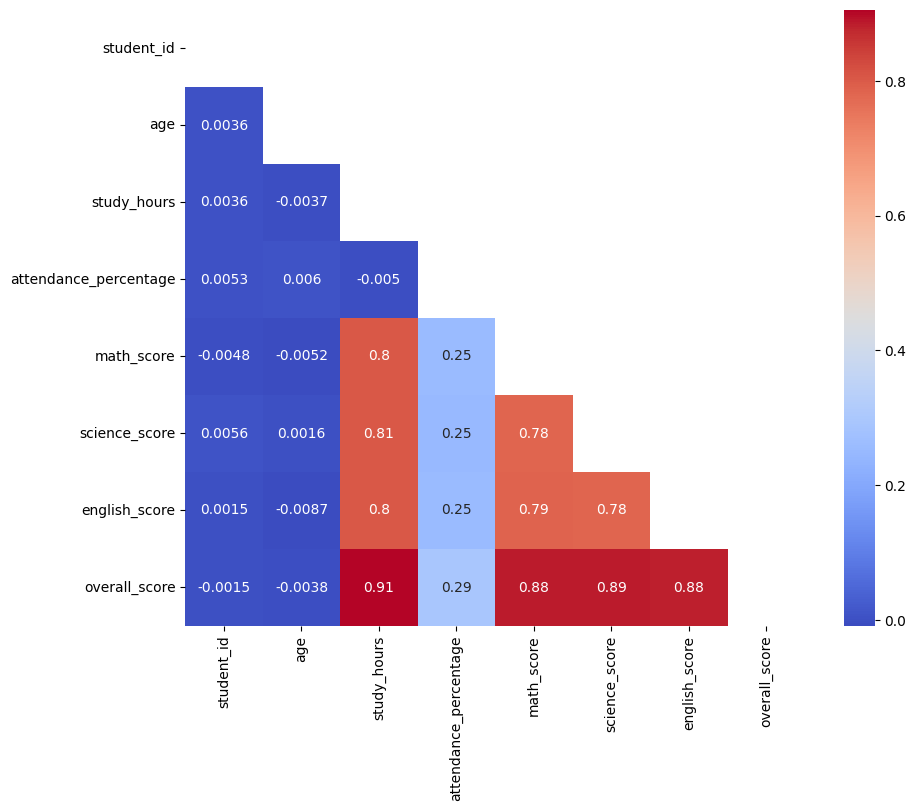

In [9]:
# plt.figure(figsize=(6, 10))
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm')
plt.show()

<span style="background-color:yellow;  color:black; padding:6px;"> **Create another DF for EDA :**  \n\n **EDA Bird View** </span>

In [10]:
EDA_df = pd.read_csv("E:\Documents\AI\Student_Performance\Data\Student_Performance.csv")

<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
<>:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
C:\Users\ASUD Vivo\AppData\Local\Temp\ipykernel_3548\3831817297.py:1: SyntaxWarning: "\D" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\D"? A raw string is also an option.
  EDA_df = pd.read_csv("E:\Documents\AI\Student_Performance\Data\Student_Performance.csv")


In [11]:
EDA_df.dtypes

student_id                 int64
age                        int64
gender                       str
school_type                  str
parent_education             str
study_hours              float64
attendance_percentage    float64
internet_access              str
travel_time                  str
extra_activities             str
study_method                 str
math_score               float64
science_score            float64
english_score            float64
overall_score            float64
final_grade                  str
dtype: object

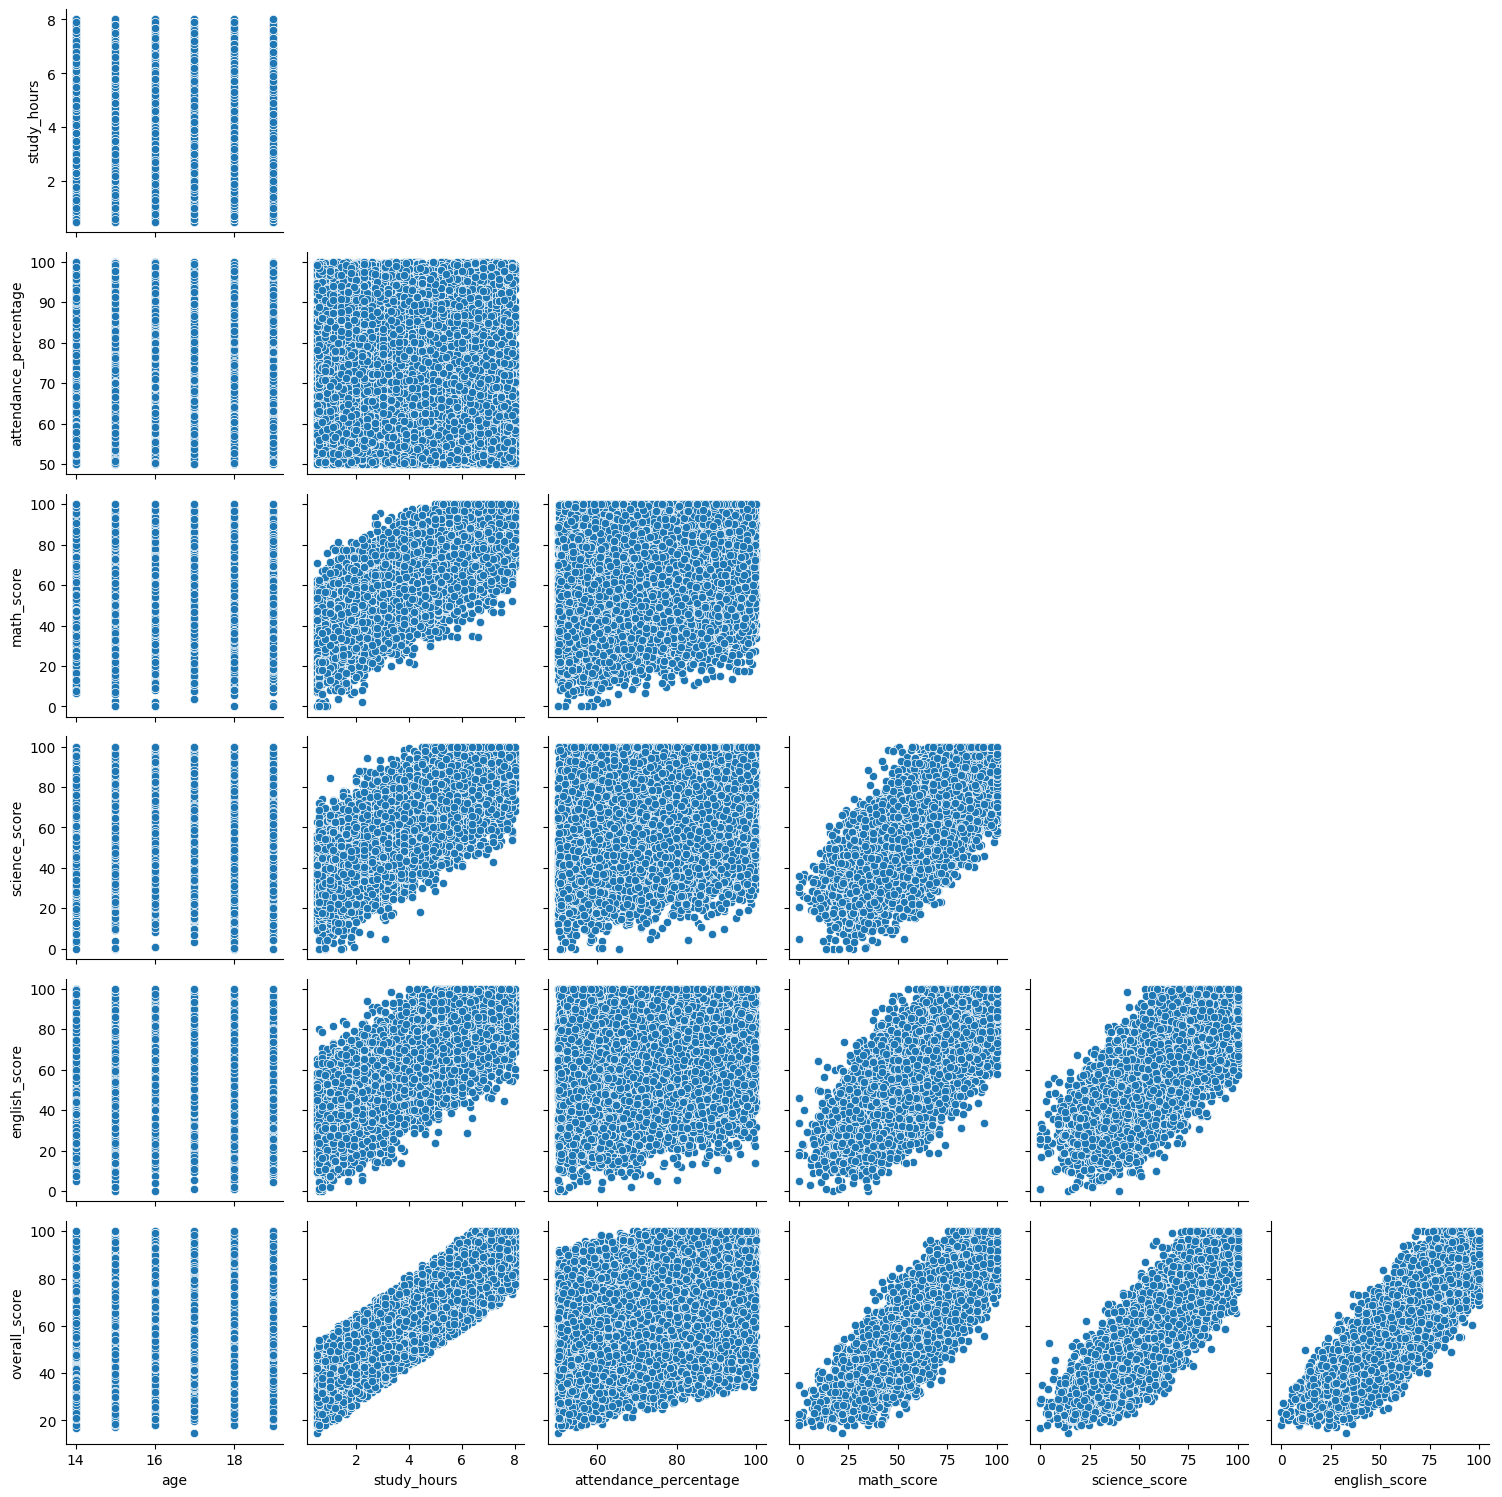

In [12]:

g = sns.PairGrid(EDA_df.iloc[: , 1:])

# رسم lower triangle بس
g.map_lower(sns.scatterplot)

# 🔹 حذف upper triangle
for i, j in zip(*np.triu_indices_from(g.axes, k=1)):
    g.axes[i, j].set_visible(False)

# 🔹 حذف diagonal (self vs self)
for i in range(len(g.axes)):
    g.axes[i, i].set_visible(False)

plt.tight_layout()
plt.show()

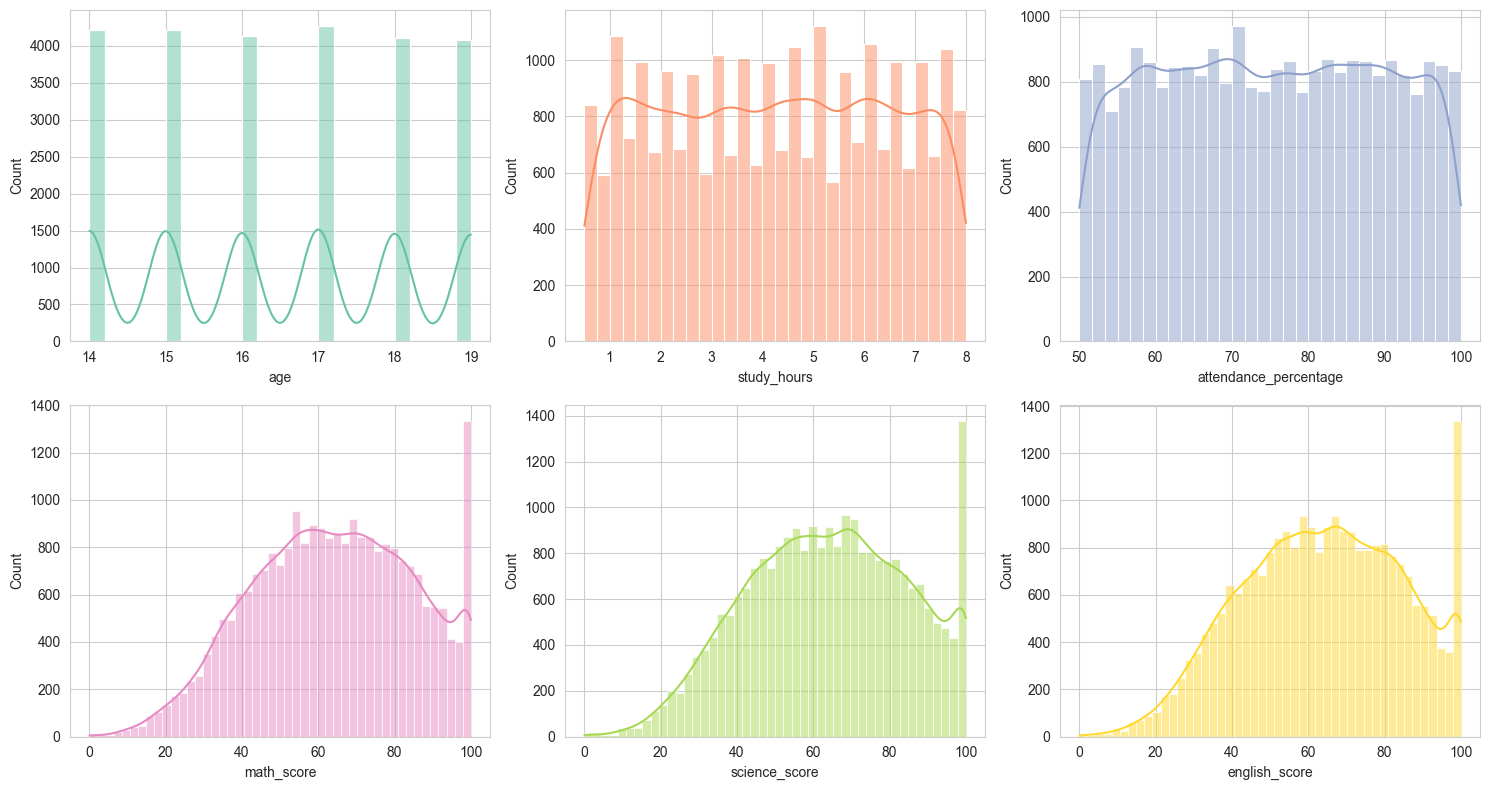

In [13]:
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

cols = ['age', 'study_hours', 'attendance_percentage',
        'math_score', 'science_score', 'english_score']

colors = sns.color_palette("Set2", len(cols))

for i, col in enumerate(cols):
    sns.histplot(df[col], ax=axes[i//3, i%3], color=colors[i], kde=True)

plt.tight_layout()
plt.show()

In [14]:
EDA_df.select_dtypes(include="number").skew()

student_id              -0.001244
age                      0.010029
study_hours             -0.007268
attendance_percentage   -0.002747
math_score              -0.148016
science_score           -0.135298
english_score           -0.141468
overall_score           -0.044512
dtype: float64

# 📊 EDA Quick Notes

## 🔹 Numerical Relations

* study_hours vs score → scatterplot
* attendance vs score → scatterplot
* study_hours vs attendance → scatterplot

✔️ used: scatterplot + corr()

---

## 🔹 Binary / Categorical Impact

* external_activities vs score → boxplot
* school_type vs score → boxplot

✔️ used: boxplot + groupby mean

---

## 🔹 School Type Comparison

public vs private:

* score
* attendance
* external_activities

✔️ used: groupby + mean + barplot

---

## 🔹 Parent Education

compare levels:

* score
* attendance
* study_hours
* school_type

✔️ used: groupby + mean

---

## 🔹 Study Method

* study_method vs score
* study_method vs study_hours

✔️ used: groupby + mean + barplot

---

## 🧠 Reminder

* scatter → relationships
* boxplot → distribution
* groupby → averages


<span style="background-color:yellow;  color:black; padding:6px;"> **Explore Distribution of numerical columns :** </span>

In [15]:
numerical_columns = ['study_hours',
       'attendance_percentage',
       'math_score', 'science_score', 'english_score',
       'overall_score' 
       ]

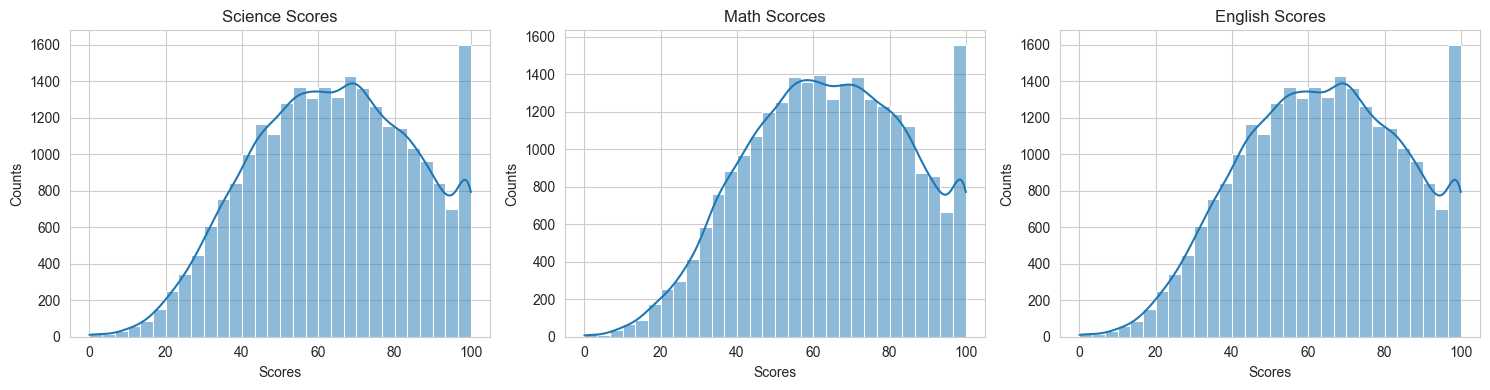

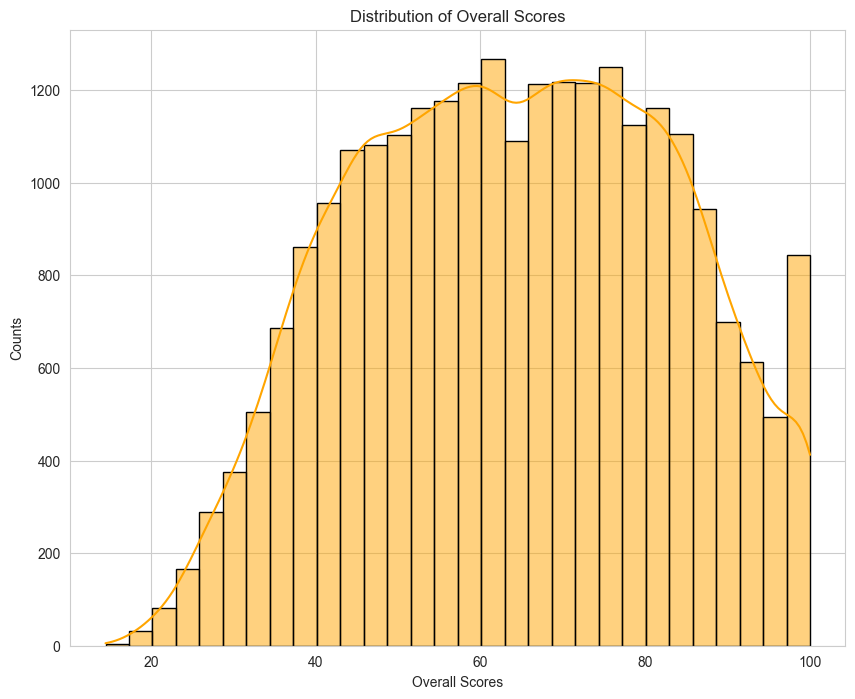

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

data = df['science_score']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1
sns.histplot(df["science_score"], bins=30, kde = True, ax =  axes[0])
axes[0].set_title("Science Scores")
axes[0].set_xlabel("Scores")
axes[0].set_ylabel("Counts")

#2
sns.histplot(df["math_score"], bins=30, kde = True, ax =  axes[1])
axes[1].set_title("Math Scorces")
axes[1].set_xlabel("Scores")
axes[1].set_ylabel("Counts")

# 3
sns.histplot(df["science_score"], bins=30, kde = True, ax =  axes[2])
axes[2].set_title("English Scores")
axes[2].set_xlabel("Scores")
axes[2].set_ylabel("Counts")

plt.tight_layout()
plt.show()

plt.figure(figsize = (10, 8))
sns.histplot(df['overall_score'], color = "orange", edgecolor= "black", bins = 30, kde = True)
plt.xlabel("Overall Scores")
plt.ylabel("Counts")
plt.title("Distribution of Overall Scores")
plt.grid(True)

Public vs Private - Summary


,school_type_clean,student_count,external_activities_rate,avg_overall_score,median_overall_score,avg_attendance,median_attendance
0,private,12725,49.44,63.99,64.0,75.15,75.1
1,public,12275,50.58,64.03,64.4,75.02,75.1


Difference (Private - Public)


,external_activities_rate,avg_overall_score,avg_attendance
private_minus_public,-1.14,-0.04,0.13


External Activities Breakdown (%)


extra_activities,no,yes
school_type_clean,,
private,50.56,49.44
public,49.42,50.58


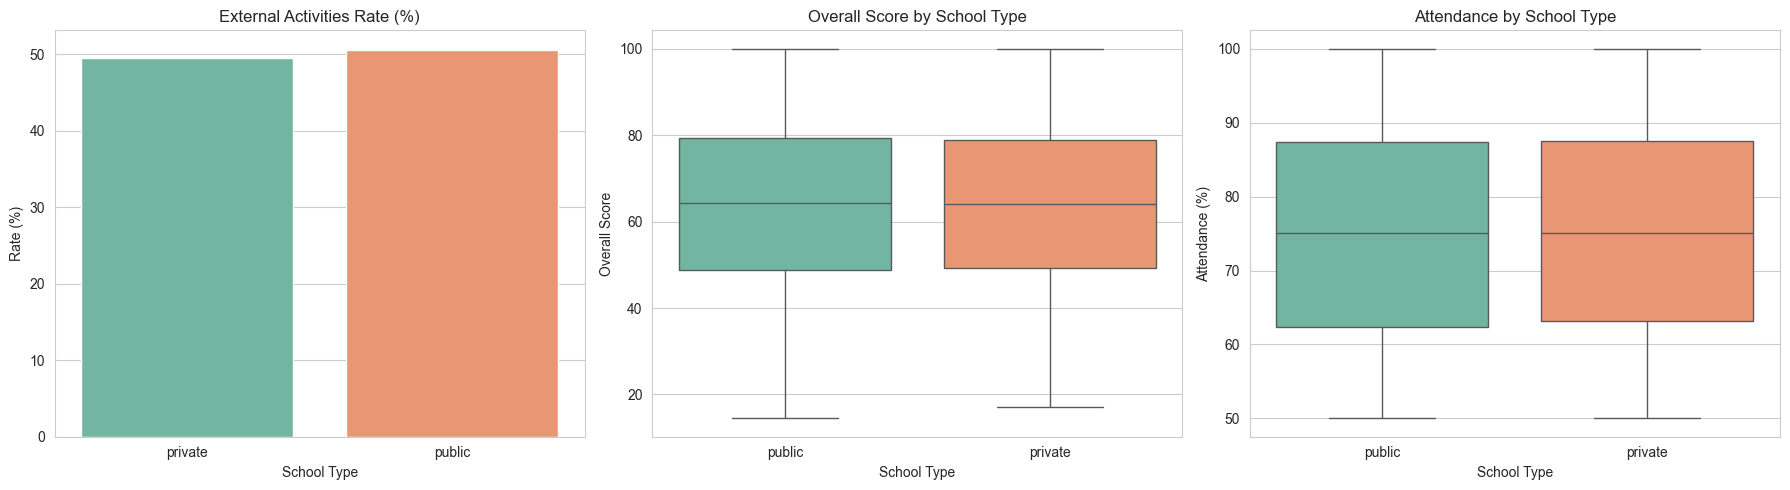

In [ ]:
# Full comparison between public and private schools
comparison_df = EDA_df.copy()

# Normalize school type labels
if pd.api.types.is_numeric_dtype(comparison_df["school_type"]):
    comparison_df["school_type_clean"] = comparison_df["school_type"].map({0: "public", 1: "private"})
else:
    comparison_df["school_type_clean"] = (
        comparison_df["school_type"].astype(str).str.strip().str.lower()
    )

comparison_df = comparison_df[comparison_df["school_type_clean"].isin(["public", "private"])].copy()

# Normalize extra activities to numeric flag for rate calculation
if pd.api.types.is_numeric_dtype(comparison_df["extra_activities"]):
    comparison_df["extra_activities_flag"] = comparison_df["extra_activities"].astype(float)
else:
    comparison_df["extra_activities_flag"] = (
        comparison_df["extra_activities"]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
    )

summary = (
    comparison_df.groupby("school_type_clean", as_index=False)
    .agg(
        student_count=("overall_score", "size"),
        external_activities_rate=("extra_activities_flag", "mean"),
        avg_overall_score=("overall_score", "mean"),
        median_overall_score=("overall_score", "median"),
        avg_attendance=("attendance_percentage", "mean"),
        median_attendance=("attendance_percentage", "median"),
    )
    .sort_values("school_type_clean")
)

summary["external_activities_rate"] = summary["external_activities_rate"] * 100
summary = summary.round({
    "external_activities_rate": 2,
    "avg_overall_score": 2,
    "median_overall_score": 2,
    "avg_attendance": 2,
    "median_attendance": 2,
})

print("Public vs Private - Summary")
display(summary)

# Difference table: private - public
if set(["public", "private"]).issubset(summary["school_type_clean"].tolist()):
    diff = (
        summary.set_index("school_type_clean")
        .loc["private", ["external_activities_rate", "avg_overall_score", "avg_attendance"]]
        - summary.set_index("school_type_clean").loc["public", ["external_activities_rate", "avg_overall_score", "avg_attendance"]]
    )
    diff = diff.rename("private_minus_public").to_frame().T.round(2)

    print("Difference (Private - Public)")
    display(diff)

# Extra activities breakdown (%) inside each school type
activity_breakdown = pd.crosstab(
    comparison_df["school_type_clean"],
    comparison_df["extra_activities"],
    normalize="index"
).mul(100).round(2)

print("External Activities Breakdown (%)")
display(activity_breakdown)

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=summary,
    x="school_type_clean",
    y="external_activities_rate",
    hue="school_type_clean",
    palette="Set2",
    legend=False,
    ax=axes[0],
)
axes[0].set_title("External Activities Rate (%)")
axes[0].set_xlabel("School Type")
axes[0].set_ylabel("Rate (%)")

sns.boxplot(
    data=comparison_df,
    x="school_type_clean",
    y="overall_score",
    hue="school_type_clean",
    palette="Set2",
    legend=False,
    dodge=False,
    ax=axes[1],
)
axes[1].set_title("Overall Score by School Type")
axes[1].set_xlabel("School Type")
axes[1].set_ylabel("Overall Score")

sns.boxplot(
    data=comparison_df,
    x="school_type_clean",
    y="attendance_percentage",
    hue="school_type_clean",
    palette="Set2",
    legend=False,
    dodge=False,
    ax=axes[2],
)
axes[2].set_title("Attendance by School Type")
axes[2].set_xlabel("School Type")
axes[2].set_ylabel("Attendance (%)")

plt.tight_layout()
plt.show()

Parent Education Level - Full Comparison


,parent_education_clean,student_count,avg_attendance,median_attendance,avg_study_hours,median_study_hours,avg_overall_score,median_overall_score,private_school_rate
3,no formal,4079,75.17,75.0,4.23,4.3,63.91,64.1,51.34
2,high school,4205,75.03,75.3,4.18,4.2,63.39,62.8,51.56
0,diploma,4314,75.04,75.1,4.34,4.5,64.65,65.8,51.16
1,graduate,4127,75.17,75.5,4.23,4.2,63.96,64.1,50.21
5,post graduate,4196,75.32,74.9,4.30,4.3,64.56,65.1,51.60
4,phd,4079,74.77,74.6,4.24,4.3,63.54,63.4,49.50


School Type Mix (%) by Parent Education


school_type_clean,private,public
parent_education_clean,,
no formal,51.34,48.66
high school,51.56,48.44
diploma,51.16,48.84
graduate,50.21,49.79
post graduate,51.60,48.40
phd,49.50,50.50


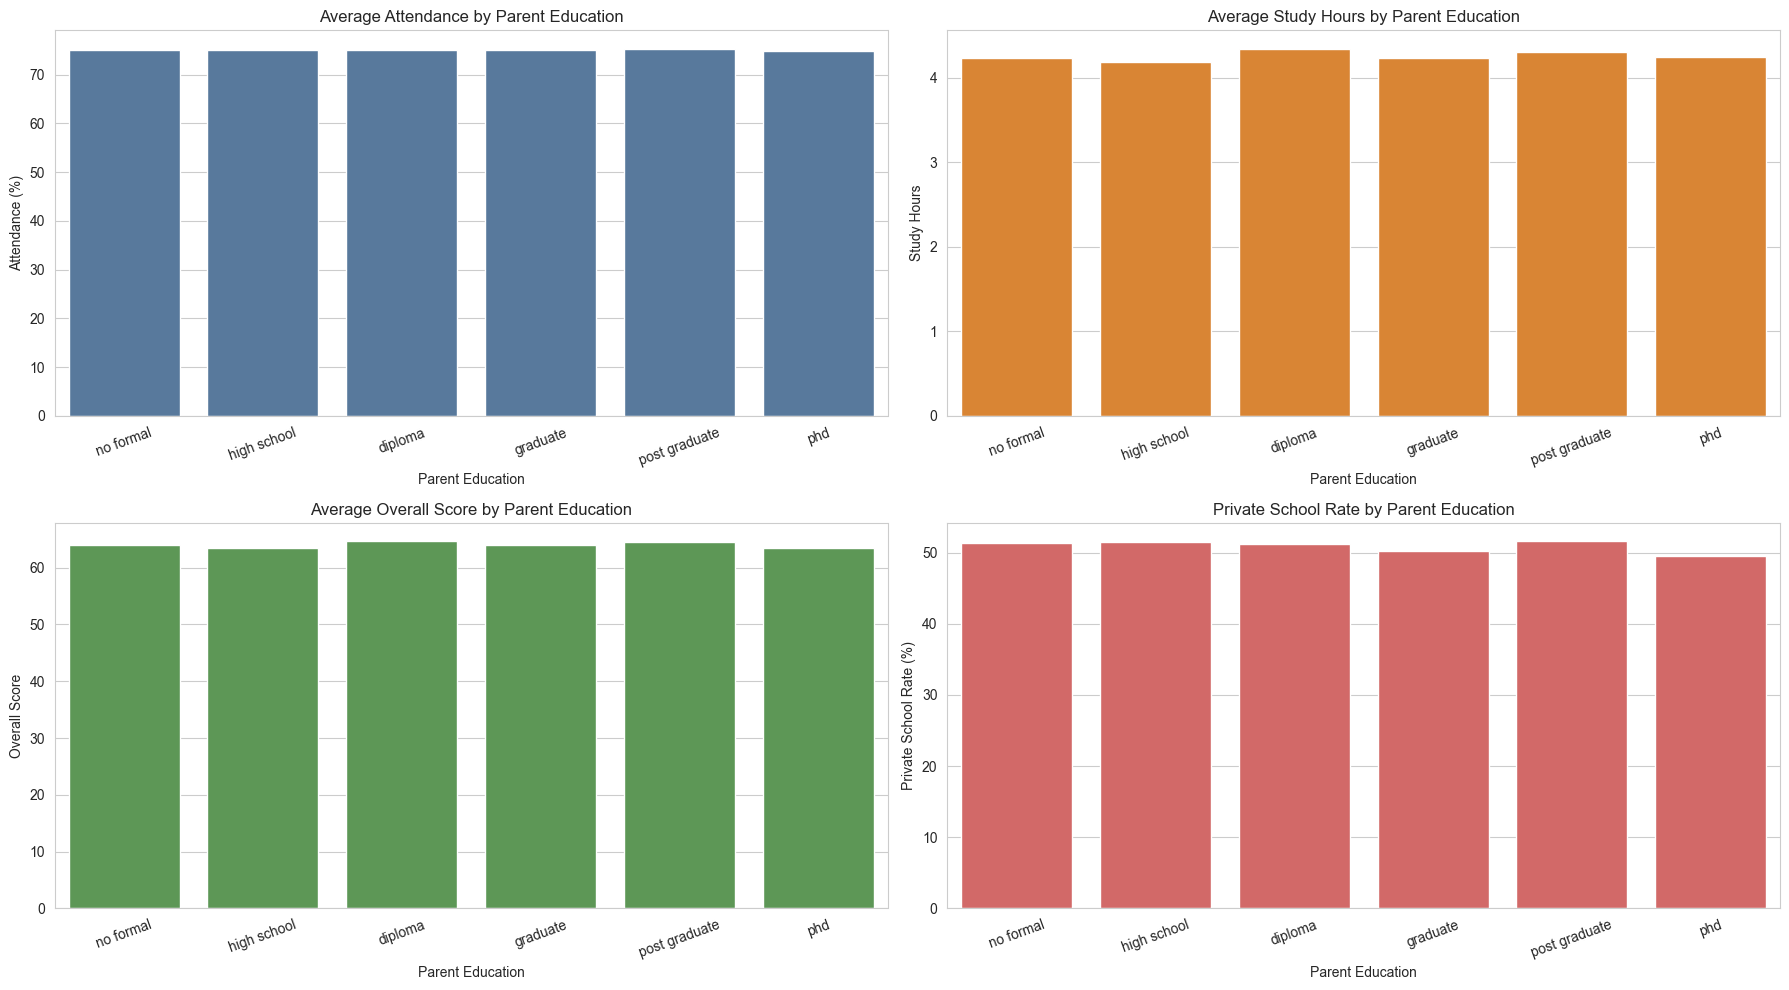

In [ ]:
# Full comparison among students by parent education level
parent_df = EDA_df.copy()

# Clean labels
parent_df["parent_education_clean"] = (
    parent_df["parent_education"].astype(str).str.strip().str.lower()
)

# Normalize school type labels
if pd.api.types.is_numeric_dtype(parent_df["school_type"]):
    parent_df["school_type_clean"] = parent_df["school_type"].map({0: "public", 1: "private"})
else:
    parent_df["school_type_clean"] = (
        parent_df["school_type"].astype(str).str.strip().str.lower()
    )

parent_df = parent_df[parent_df["parent_education_clean"].ne("nan")].copy()
parent_df["is_private"] = parent_df["school_type_clean"].map({"private": 1, "public": 0})

parent_order = ["no formal", "high school", "diploma", "graduate", "post graduate", "phd"]
available_levels = parent_df["parent_education_clean"].dropna().unique().tolist()
ordered_levels = [lvl for lvl in parent_order if lvl in available_levels]
ordered_levels += sorted(set(available_levels) - set(ordered_levels))

parent_summary = (
    parent_df.groupby("parent_education_clean", as_index=False)
    .agg(
        student_count=("overall_score", "size"),
        avg_attendance=("attendance_percentage", "mean"),
        median_attendance=("attendance_percentage", "median"),
        avg_study_hours=("study_hours", "mean"),
        median_study_hours=("study_hours", "median"),
        avg_overall_score=("overall_score", "mean"),
        median_overall_score=("overall_score", "median"),
        private_school_rate=("is_private", "mean"),
    )
)

parent_summary["private_school_rate"] = parent_summary["private_school_rate"] * 100
parent_summary["parent_education_clean"] = pd.Categorical(
    parent_summary["parent_education_clean"],
    categories=ordered_levels,
    ordered=True,
 )
parent_summary = parent_summary.sort_values("parent_education_clean")

parent_summary = parent_summary.round({
    "avg_attendance": 2,
    "median_attendance": 2,
    "avg_study_hours": 2,
    "median_study_hours": 2,
    "avg_overall_score": 2,
    "median_overall_score": 2,
    "private_school_rate": 2,
})

print("Parent Education Level - Full Comparison")
display(parent_summary)

school_type_mix = (
    pd.crosstab(
        parent_df["parent_education_clean"],
        parent_df["school_type_clean"],
        normalize="index",
    )
    .mul(100)
    .reindex(ordered_levels)
    .round(2)
)

print("School Type Mix (%) by Parent Education")
display(school_type_mix)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

sns.barplot(
    data=parent_summary,
    x="parent_education_clean",
    y="avg_attendance",
    color="#4C78A8",
    ax=axes[0, 0],
)
axes[0, 0].set_title("Average Attendance by Parent Education")
axes[0, 0].set_xlabel("Parent Education")
axes[0, 0].set_ylabel("Attendance (%)")

sns.barplot(
    data=parent_summary,
    x="parent_education_clean",
    y="avg_study_hours",
    color="#F58518",
    ax=axes[0, 1],
)
axes[0, 1].set_title("Average Study Hours by Parent Education")
axes[0, 1].set_xlabel("Parent Education")
axes[0, 1].set_ylabel("Study Hours")

sns.barplot(
    data=parent_summary,
    x="parent_education_clean",
    y="avg_overall_score",
    color="#54A24B",
    ax=axes[1, 0],
)
axes[1, 0].set_title("Average Overall Score by Parent Education")
axes[1, 0].set_xlabel("Parent Education")
axes[1, 0].set_ylabel("Overall Score")

sns.barplot(
    data=parent_summary,
    x="parent_education_clean",
    y="private_school_rate",
    color="#E45756",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Private School Rate by Parent Education")
axes[1, 1].set_xlabel("Parent Education")
axes[1, 1].set_ylabel("Private School Rate (%)")

for ax in axes.flatten():
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

,column,n_unique,unique_values
0,gender,3,"[male, female, other]"
1,school_type,2,"[public, private]"
2,parent_education,6,"[post graduate, graduate, high school, no form..."
3,internet_access,2,"[yes, no]"
4,travel_time,4,"[<15 min, >60 min, 15-30 min, 30-60 min]"
5,extra_activities,2,"[yes, no]"
6,study_method,6,"[notes, textbook, group study, coaching, mixed]"
7,final_grade,6,"[e, d, b, f, c]"


Study Method - Full Comparison


,study_method_clean,student_count,avg_study_hours,avg_overall_score,math_score,science_score,english_score,highest_subject
3,notes,4165,4.26,63.90,64.01,63.44,63.72,Math
5,textbook,4239,4.26,64.24,63.91,64.37,63.59,Science
1,group study,4090,4.18,63.25,62.97,63.09,62.98,Science
4,online videos,4139,4.32,64.69,64.11,64.31,64.34,English
0,coaching,4026,4.26,64.37,64.21,64.06,64.08,Math
2,mixed,4341,4.24,63.61,63.52,63.20,63.39,Math


Study Method - Full Comparison


,study_method_clean,student_count,avg_study_hours,avg_overall_score,math_score,science_score,english_score,highest_subject
3,notes,4165,4.26,63.90,64.01,63.44,63.72,Math
5,textbook,4239,4.26,64.24,63.91,64.37,63.59,Science
1,group study,4090,4.18,63.25,62.97,63.09,62.98,Science
4,online videos,4139,4.32,64.69,64.11,64.31,64.34,English
0,coaching,4026,4.26,64.37,64.21,64.06,64.08,Math
2,mixed,4341,4.24,63.61,63.52,63.20,63.39,Math


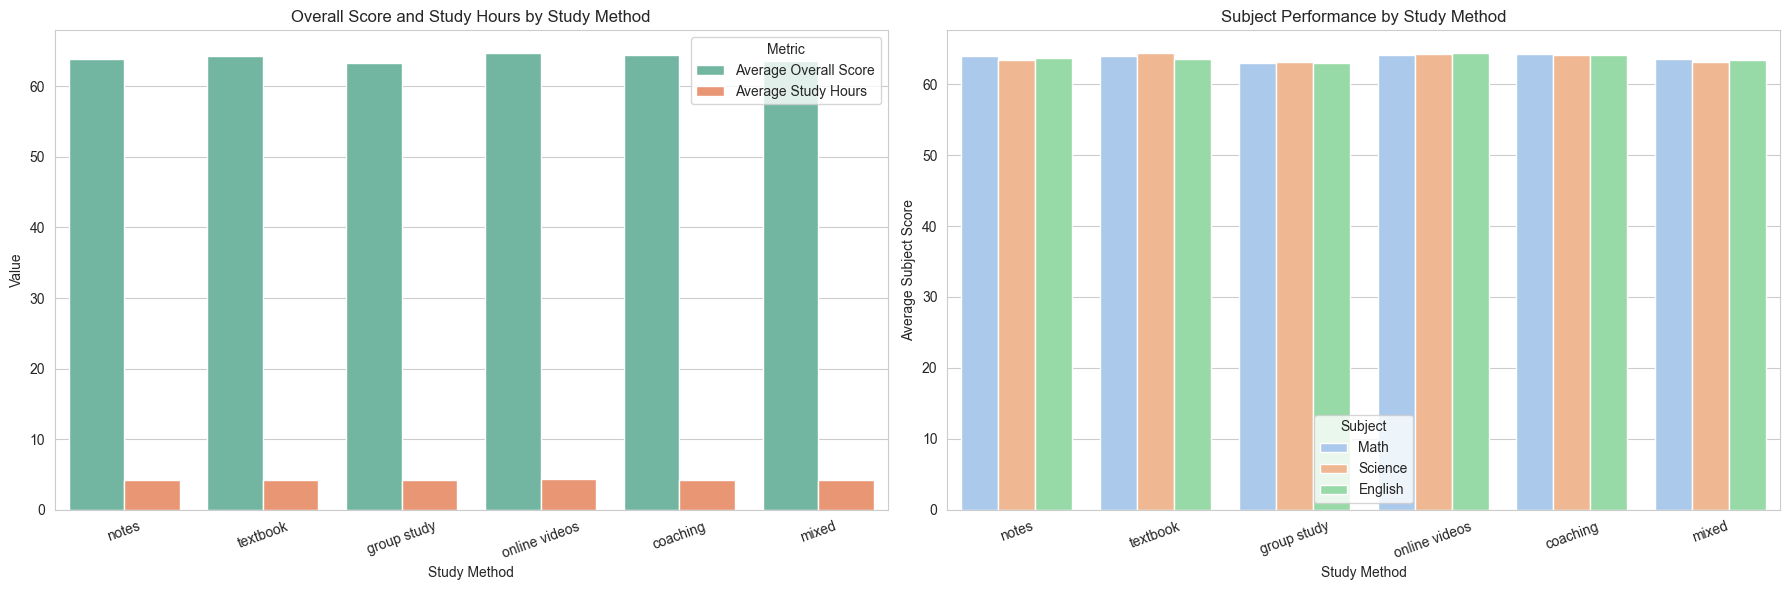

Best study method by average overall score: online videos
Study method with the highest average study hours: online videos
Highest subject for each study method:


,study_method_clean,highest_subject
3,notes,Math
5,textbook,Science
1,group study,Science
4,online videos,English
0,coaching,Math
2,mixed,Math


In [33]:
categorical_cols = []

for col in df.columns:
    if (
        df[col].dtype == 'object' 
        or (df[col].nunique() < 10 and df[col].dtype not in ['float64', 'int64'])
    ):
        categorical_cols.append(col)

non_numerical_categories = pd.DataFrame({
    "column": categorical_cols,
    "n_unique": [df[col].nunique() for col in categorical_cols],
    "unique_values": [list(df[col].unique())[:5] for col in categorical_cols]
})

non_numerical_categories


# 📊 Data Preprocessing Notes

## 🔹 Categorical Features
These columns represent categories (no direct numerical meaning):

- gender            →  one hot encoding - drop first
- parent_education   → ordinal map()
- travel_time       →  ordinal map()
- study_method       → one hot encoding - drop first
- final_grade        → ordinal map()

---

## 🔹 Binary Features (Boolean Encoding)
Convert these columns to binary:

- internet_access → 1 = yes, 0 = no  
- extra_activities → 1 = yes, 0 = no 
-  school_type


---

## 🔹 Numerical Features
Keep these columns as they are (continuous values):

- scores (and other numeric columns like study_hours, attendance_percentage)

---

## 🧠 Notes / Decisions

- Categorical features will require encoding (One-Hot or Ordinal based on context)
- Binary features will be mapped directly to 0/1
- Numerical features will remain unchanged

<span style="background-color:yellow;  color:black; padding:6px;"> **binary columns handing :** </span>

In [20]:
df["internet_access"] = df["internet_access"].map({"yes": 1, "no": 0})
df["extra_activities"] = df["extra_activities"].map({"yes": 1, "no":0})
df["school_type"] = df["school_type"].map({"public" : 0, "private" : 1})

<span style="background-color:yellow;  color:black; padding:6px;"> **Categorical columns handing :** </span>

In [21]:
# One Hot Encoding :)
df = pd.get_dummies(df, columns=['gender', 'study_method'], drop_first=True)

# Mapping

df["parent_education"] = df["parent_education"].map({"no formal": 0, "high school": 1 , "diploma" : 2, "graduate" : 3, "post graduate": 4 , "phd": 5})
df["travel_time"] = df["travel_time"].map({"<15 min": 0, ">60 min" : 3, "15-30 min" : 1, "30-60 min" : 2})
df["final_grade"] = df["final_grade"].map({'f': 0, 'a': 5, 'b': 4, 'c': 3, 'd': 2, 'e': 1})



In [22]:
df

,student_id,age,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,math_score,...,english_score,overall_score,final_grade,gender_male,gender_other,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
0,1,14,0,4,3.1,84.3,1,0,1,42.7,...,57.0,53.1,1,True,False,False,False,True,False,False
1,2,18,0,3,3.7,87.8,1,3,0,57.6,...,64.8,61.3,2,False,False,False,False,False,False,True
2,3,17,1,4,7.9,65.5,0,0,0,84.8,...,79.2,89.6,4,False,False,False,False,True,False,False
3,4,16,0,1,1.1,58.1,0,1,0,44.4,...,54.7,41.6,1,False,True,False,False,True,False,False
4,5,16,0,1,1.3,61.0,1,2,1,8.9,...,30.0,25.4,0,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,12047,17,0,5,1.8,55.2,1,1,0,55.8,...,46.7,46.1,1,False,False,False,True,False,False,False
24996,1102,16,1,2,2.7,97.1,1,0,0,64.8,...,52.3,56.5,2,False,False,False,False,False,False,False
24997,4422,19,1,4,1.0,63.0,1,0,0,50.5,...,36.1,36.7,0,False,True,True,False,False,False,False
24998,7858,14,1,2,1.0,69.4,1,1,1,13.0,...,7.3,34.1,0,True,False,True,False,False,False,False


## 📌 Data Processing for Machine Learning

* Prepare and preprocess the dataset
* Apply a linear algebra-based model
* Use the `scikit-learn` library for implementation


In [ ]:

#! drop student id column -> unnessary column for ML 
df.drop(columns = ["student_id"], inplace = True)
df

,age,school_type,parent_education,study_hours,attendance_percentage,internet_access,travel_time,extra_activities,math_score,science_score,english_score,overall_score,final_grade,gender_male,gender_other,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
0,14,0,4,3.1,84.3,1,0,1,42.7,55.4,57.0,53.1,1,True,False,False,False,True,False,False
1,18,0,3,3.7,87.8,1,3,0,57.6,68.8,64.8,61.3,2,False,False,False,False,False,False,True
2,17,1,4,7.9,65.5,0,0,0,84.8,95.0,79.2,89.6,4,False,False,False,False,True,False,False
3,16,0,1,1.1,58.1,0,1,0,44.4,27.5,54.7,41.6,1,False,True,False,False,True,False,False
4,16,0,1,1.3,61.0,1,2,1,8.9,32.7,30.0,25.4,0,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24995,17,0,5,1.8,55.2,1,1,0,55.8,48.5,46.7,46.1,1,False,False,False,True,False,False,False
24996,16,1,2,2.7,97.1,1,0,0,64.8,48.2,52.3,56.5,2,False,False,False,False,False,False,False
24997,19,1,4,1.0,63.0,1,0,0,50.5,20.3,36.1,36.7,0,False,True,True,False,False,False,False
24998,14,1,2,1.0,69.4,1,1,1,13.0,34.2,7.3,34.1,0,True,False,True,False,False,False,False


In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   age                         25000 non-null  int64  
 1   school_type                 25000 non-null  int64  
 2   parent_education            25000 non-null  int64  
 3   study_hours                 25000 non-null  float64
 4   attendance_percentage       25000 non-null  float64
 5   internet_access             25000 non-null  int64  
 6   travel_time                 25000 non-null  int64  
 7   extra_activities            25000 non-null  int64  
 8   math_score                  25000 non-null  float64
 9   science_score               25000 non-null  float64
 10  english_score               25000 non-null  float64
 11  overall_score               25000 non-null  float64
 12  final_grade                 25000 non-null  int64  
 13  gender_male                 25000 non-null

<span style="background-color:yellow;  color:black; padding:6px;"> **Select final features:** </span>

In [44]:
# Select final features for modeling
if "df" not in globals():
    raise ValueError("Run preprocessing cells first so df is available.")

target_col = "overall_score"

# Avoid leakage from target or target-derived labels
leakage_cols = ["overall_score", "final_grade", "science_score", "math_score", "english_score"]

# Core behavioral + context features
base_features = [
    "age",
    "study_hours",
    "attendance_percentage",
    "internet_access",
    "extra_activities",
    "school_type",
    "parent_education",
    "travel_time",
]

# One-hot encoded columns created from categorical variables
dummy_features = [
    col
    for col in df.columns
    if col.startswith("gender_") or col.startswith("study_method_")
]

final_features = [
    col for col in (base_features + dummy_features)
    if col in df.columns and col not in leakage_cols
]

X = df[final_features].copy()
y = df[target_col].copy()

# Convert bool dummies to 0/1 for model compatibility
bool_cols = X.select_dtypes(include="bool").columns
if len(bool_cols) > 0:
    X[bool_cols] = X[bool_cols].astype(int)

print("Final selected features:")
print(final_features)
print(f"Number of features: {len(final_features)}")
print(f"Converted bool columns: {list(bool_cols)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X.head()

Final selected features:
['age', 'study_hours', 'attendance_percentage', 'internet_access', 'extra_activities', 'school_type', 'parent_education', 'travel_time', 'gender_male', 'gender_other', 'study_method_group study', 'study_method_mixed', 'study_method_notes', 'study_method_online videos', 'study_method_textbook']
Number of features: 15
Converted bool columns: ['gender_male', 'gender_other', 'study_method_group study', 'study_method_mixed', 'study_method_notes', 'study_method_online videos', 'study_method_textbook']
X shape: (25000, 15)
y shape: (25000,)


,age,study_hours,attendance_percentage,internet_access,extra_activities,school_type,parent_education,travel_time,gender_male,gender_other,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
0,14,3.1,84.3,1,1,0,4,0,1,0,0,0,1,0,0
1,18,3.7,87.8,1,0,0,3,3,0,0,0,0,0,0,1
2,17,7.9,65.5,0,0,1,4,0,0,0,0,0,1,0,0
3,16,1.1,58.1,0,0,0,1,1,0,1,0,0,1,0,0
4,16,1.3,61.0,1,1,0,1,2,0,0,1,0,0,0,0


<span style="background-color:yellow;  color:black; padding:6px;"> **Upply scalling:** </span>

In [47]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

if "X" not in globals():
    raise ValueError("Run the feature selection cell first so X is available.")

Scaled_features = ["study_hours" , "attendance_percentage" ,  "age" ,  "parent_education" ,  "travel_time" ]

scaler = StandardScaler()
X_scaled_features = pd.DataFrame(
    scaler.fit_transform(X[Scaled_features]),
    columns=Scaled_features ,
    index=X.index,
 )

X_scaled = X.copy()
X_scaled[Scaled_features] = X_scaled_features 

X_scaled.head() 

,age,study_hours,attendance_percentage,internet_access,extra_activities,school_type,parent_education,travel_time,gender_male,gender_other,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
0,-1.457138,-0.532053,0.641202,1,1,0,0.886408,-1.352420,1,0,0,0,1,0,0
1,0.890472,-0.255236,0.884716,1,0,0,0.297151,1.348818,0,0,0,0,0,0,1
2,0.303569,1.682482,-0.666817,0,0,1,0.886408,-1.352420,0,0,0,0,1,0,0
3,-0.283333,-1.454776,-1.181675,0,0,0,-0.881364,-0.452007,0,1,0,0,1,0,0
4,-0.283333,-1.362504,-0.979907,1,1,0,-0.881364,0.448406,0,0,1,0,0,0,0


In [ ]:
from sklearn.model_selection import train_test_split

X_model = X_scaled
source_name = "X_scaled"

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
 )

print(f"Feature source used: {source_name}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train.head()

Feature source used: X_scaled
X_train shape: (20000, 15)
X_test shape:  (5000, 15)
y_train shape: (20000,)
y_test shape:  (5000,)


,age,study_hours,attendance_percentage,internet_access,extra_activities,school_type,parent_education,travel_time,gender_male,gender_other,study_method_group study,study_method_mixed,study_method_notes,study_method_online videos,study_method_textbook
23311,-1.457138,1.128848,-1.112100,1,0,0,0.886408,-1.352420,1,0,0,0,0,1,0
23623,1.477374,-1.454776,-1.327784,1,1,1,-0.881364,1.348818,0,0,0,0,0,0,0
1020,-1.457138,0.252261,1.023867,0,0,1,0.886408,-1.352420,1,0,0,0,0,1,0
12645,1.477374,0.206125,1.190848,1,1,1,1.475666,0.448406,1,0,0,0,0,0,1
1533,-0.870235,0.713623,-1.564341,1,0,0,0.297151,-0.452007,0,1,0,1,0,0,0


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

y_pred = lin_reg.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R2  : {r2:.4f}")

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coefficient": lin_reg.coef_,
}).sort_values("coefficient", key=lambda s: s.abs(), ascending=False)

print("\nTop 10 important features by absolute coefficient:")
display(coef_df.head(10))

Linear Regression Performance
MAE : 5.0113
RMSE: 5.7813
R2  : 0.9079

Top 10 important features by absolute coefficient:


,feature,coefficient
1,study_hours,17.175370
2,attendance_percentage,5.634651
11,study_method_mixed,-0.313176
9,gender_other,-0.269749
5,school_type,-0.141802
4,extra_activities,-0.119164
13,study_method_online videos,0.109116
14,study_method_textbook,-0.090744
8,gender_male,-0.066893
0,age,-0.064696


Model Evaluation Summary


,Metric,Value
0,MAE,5.011320
1,RMSE,5.781347
2,R2,0.907941
3,MAPE (%),8.822581
4,Bias (Mean Residual),5.011320


Error Bucket Distribution


,count,percentage
abs_error,,
0-2,978,19.56
2-5,1502,30.04
5-10,2467,49.34
>10,53,1.06


Top 10 Largest Prediction Errors


,actual,predicted,residual,abs_error
16451,98.4,87.632300,10.767700,10.767700
12036,95.5,84.944996,10.555004,10.555004
6515,88.7,78.208619,10.491381,10.491381
7799,96.2,85.831156,10.368844,10.368844
11377,23.8,34.144416,-10.344416,10.344416
3595,98.9,88.576651,10.323349,10.323349
11214,85.9,75.578038,10.321962,10.321962
8113,98.1,87.789995,10.310005,10.310005
17339,77.1,66.808677,10.291323,10.291323
3111,98.9,88.620048,10.279952,10.279952


Error Summary by School Type


,school_type,count,mae,rmse,bias
0,private,2529,4.9992,5.7798,0.1272
1,public,2471,5.0237,5.7830,0.0496


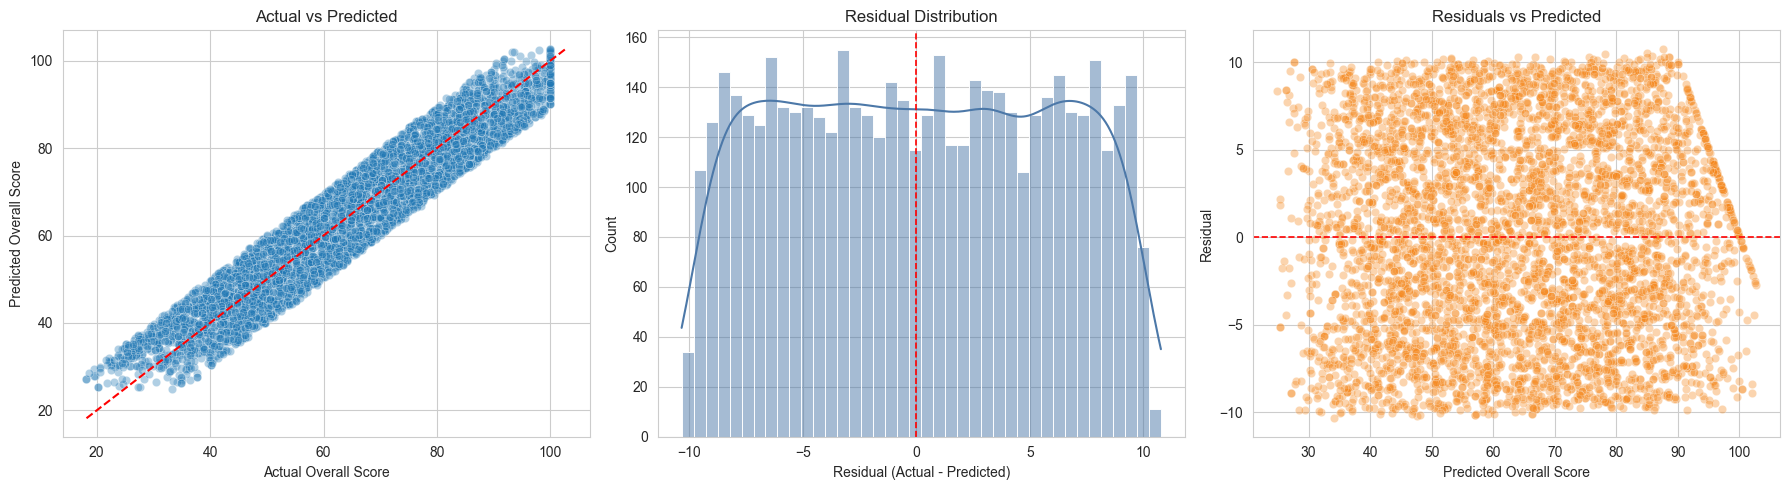

In [ ]:

# Core evaluation metrics
mae_eval = mean_absolute_error(y_test, y_pred)
rmse_eval = np.sqrt(mean_squared_error(y_test, y_pred))
r2_eval = r2_score(y_test, y_pred)

residuals = y_test - y_pred
abs_errors = residuals.abs()
mape = (abs_errors / y_test.abs().replace(0, np.nan)).mean() * 100
bias = residuals.mean()

metrics_df = pd.DataFrame(
    {
        "Metric": ["MAE", "RMSE", "R2", "MAPE (%)", "Bias (Mean Residual)"],
        "Value": [mae_eval, rmse_eval, r2_eval, mape, bias],
    }
)
print("Model Evaluation Summary")
display(metrics_df)

# Row-level error analysis table
error_df = pd.DataFrame(
    {
        "actual": y_test,
        "predicted": y_pred,
        "residual": residuals,
        "abs_error": abs_errors,
    },
    index=y_test.index,
).sort_values("abs_error", ascending=False)

error_cut = pd.cut(
    error_df["abs_error"],
    bins=[0, 2, 5, 10, np.inf],
    labels=["0-2", "2-5", "5-10", ">10"],
    include_lowest=True,
 )
error_bucket = (
    error_cut.value_counts(dropna=False)
    .sort_index()
    .rename("count")
    .to_frame()
 )
error_bucket["percentage"] = (error_bucket["count"] / len(error_df) * 100).round(2)

print("Error Bucket Distribution")
display(error_bucket)

print("Top 10 Largest Prediction Errors")
display(error_df.head(10))

# # Error by school type (if feature exists)
# if "school_type" in X_test.columns:
#     school_error = error_df.join(X_test[["school_type"]])
#     school_error["school_type"] = school_error["school_type"].map({0: "public", 1: "private"}).fillna("unknown")
#     school_error_summary = (
#         school_error.groupby("school_type", as_index=False)
#         .agg(
#             count=("abs_error", "size"),
#             mae=("abs_error", "mean"),
#             rmse=("residual", lambda r: np.sqrt(np.mean(r ** 2))),
#             bias=("residual", "mean"),
#         )
#         .round(4)
#     )
#     print("Error Summary by School Type")
#     display(school_error_summary)


# Diagnostic plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_test, y=y_pred, alpha=0.35, ax=axes[0])
line_min = min(y_test.min(), y_pred.min())
line_max = max(y_test.max(), y_pred.max())
axes[0].plot([line_min, line_max], [line_min, line_max], "r--", linewidth=1.5)
axes[0].set_title("Actual vs Predicted")
axes[0].set_xlabel("Actual Overall Score")
axes[0].set_ylabel("Predicted Overall Score")

sns.histplot(residuals, bins=40, kde=True, ax=axes[1], color="#4C78A8")
axes[1].axvline(0, color="red", linestyle="--", linewidth=1.2)
axes[1].set_title("Residual Distribution")
axes[1].set_xlabel("Residual (Actual - Predicted)")

sns.scatterplot(x=y_pred, y=residuals, alpha=0.35, ax=axes[2], color="#F58518")
axes[2].axhline(0, color="red", linestyle="--", linewidth=1.2)
axes[2].set_title("Residuals vs Predicted")
axes[2].set_xlabel("Predicted Overall Score")
axes[2].set_ylabel("Residual")

plt.tight_layout()
plt.show()